In [1]:
import zipfile
import io
import geopandas as gpd
import pandas as pd
from tqdm import tqdm

In [2]:
def read_lines_of_zip(zip_file_path, inner_file_name, encoding='utf-8'):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zf:
            with io.TextIOWrapper(zf.open(inner_file_name, 'r'), encoding=encoding) as f:
                return f.readlines()
    except (FileNotFoundError, KeyError, Exception) as e:
        print(f"Error reading zipped file: {e}")
        return []

In [3]:
%%time

data_path = 'opera_granules_20250623.txt.zip'

CPU times: user 9 μs, sys: 0 ns, total: 9 μs
Wall time: 18.1 μs


In [4]:
%%time

lines = read_lines_of_zip(data_path, 'opera_granules_20250623.txt')
lines = list(map(lambda x: x.strip(), lines))

CPU times: user 5.36 s, sys: 1.71 s, total: 7.07 s
Wall time: 7.07 s


In [5]:
lines[:3]

['OPERA_L2_RTC-S1_T152-325105-IW1_20231005T030621Z_20231005T233039Z_S1A_30_v1.0',
 'OPERA_L2_RTC-S1_T148-316853-IW3_20231004T204701Z_20231005T232451Z_S1A_30_v1.0',
 'OPERA_L2_RTC-S1_T148-316859-IW1_20231004T204716Z_20231005T232451Z_S1A_30_v1.0']

In [6]:
df_rtc_gran = pd.DataFrame({'opera_id': lines})
df_rtc_gran.shape

(19167261, 1)

In [7]:
%%time

df_rtc_gran['jpl_burst_id'] = df_rtc_gran.opera_id.str.split('_').str[3]

CPU times: user 23.7 s, sys: 3.35 s, total: 27.1 s
Wall time: 27 s


In [8]:
%%time
df_rtc_gran['acq_dt'] = pd.to_datetime(df_rtc_gran.opera_id.str.split('_').str[4])

CPU times: user 1min 35s, sys: 3.9 s, total: 1min 39s
Wall time: 1min 39s


In [9]:
%%time

df_rtc_gran['year'] = df_rtc_gran['acq_dt'].dt.year


CPU times: user 313 ms, sys: 52.9 ms, total: 366 ms
Wall time: 363 ms


In [10]:
%%time

df_year_counts = df_rtc_gran.groupby(['jpl_burst_id', 'year']).size().unstack(fill_value=0).reset_index(drop=False)

CPU times: user 4.7 s, sys: 1.4 s, total: 6.11 s
Wall time: 6.1 s


In [11]:
df_year_counts.columns = [f'granules_in_{col}' if isinstance(col, int) else col for col in df_year_counts.columns ]


In [12]:
df_year_counts.head()

,jpl_burst_id,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
0,T001-000010-IW1,0,0,30,32,31,14
1,T001-000010-IW2,0,0,30,32,30,14
2,T001-000010-IW3,0,0,30,32,31,14
3,T001-000011-IW1,0,0,30,32,31,14
4,T001-000011-IW2,0,0,30,32,31,14


In [13]:
from dist_s1_enumerator import get_burst_table

/u/aurora-r0/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
df_burst = get_burst_table()
df_burst.head()

,jpl_burst_id,geometry
0,T001-000025-IW3,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4...."
1,T001-000026-IW2,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3...."
2,T001-000026-IW3,"POLYGON ((3.99185 5.35497, 4.70037 5.49605, 4...."
3,T001-000027-IW1,"POLYGON ((2.46164 5.09048, 3.22658 5.24523, 3...."
4,T001-000027-IW2,"POLYGON ((3.18963 5.30788, 3.99158 5.46953, 3...."


In [15]:
df_year_counts_geo = pd.merge(df_burst, df_year_counts, on='jpl_burst_id', how='inner')
df_year_counts_geo.head()

,jpl_burst_id,geometry,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
0,T001-000025-IW3,"POLYGON ((4.02659 5.18854, 4.73485 5.32978, 4....",0,0,30,32,30,14
1,T001-000026-IW2,"POLYGON ((3.22392 5.14115, 4.02565 5.30297, 3....",0,0,30,32,30,14
2,T001-000026-IW3,"POLYGON ((3.99185 5.35497, 4.70037 5.49605, 4....",0,0,30,32,30,14
3,T001-000027-IW1,"POLYGON ((2.46164 5.09048, 3.22658 5.24523, 3....",0,0,30,32,30,14
4,T001-000027-IW2,"POLYGON ((3.18963 5.30788, 3.99158 5.46953, 3....",0,0,30,32,30,14


<Axes: >

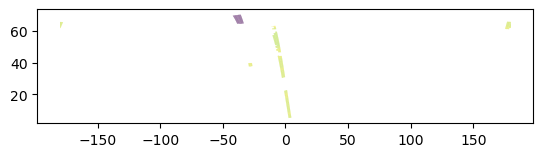

In [16]:
df_year_counts_geo.iloc[:1_000].plot(column='granules_in_2023', alpha=.5)

In [17]:
df_year_counts_geo.to_parquet('opera_rtc_burst_counts_by_year.parquet')

# MGRS Analysis

In [20]:
df_mgrs_selected = pd.read_csv('MGRS_selected.csv')
df_mgrs_selected.head()

,mgrs_tile_id
0,10TDT
1,11TLH
2,12STA
3,12UUD
4,13RCK


In [21]:
from dist_s1_enumerator import get_mgrs_table

In [23]:
df_mgrs = get_mgrs_table()
df_mgrs.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBF,32701,"MULTIPOLYGON(((199980 4600000,199980 4490200,3...","MULTIPOLYGON (((-179.58653 -48.72398, -179.638..."
2,01GBH,32701,"MULTIPOLYGON(((199980 4800040,199980 4690240,3...","MULTIPOLYGON (((-179.49865 -46.9259, -179.5458..."
3,01GDM,32701,"MULTIPOLYGON(((399960 5200000,399960 5090200,5...","POLYGON ((-178.23431 -43.34619, -178.25485 -44..."
4,01GEL,32701,"MULTIPOLYGON(((499980 5100040,499980 4990240,6...","POLYGON ((-177.00025 -44.25288, -177.00025 -45..."


<Axes: >

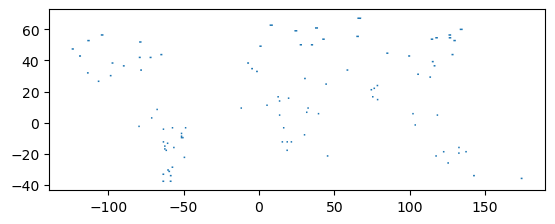

In [24]:
df_mgrs_selected = df_mgrs[df_mgrs.mgrs_tile_id.isin(df_mgrs_selected.mgrs_tile_id.tolist())].reset_index(drop=True)
df_mgrs_selected.plot()

# Analysis

In [33]:
%%time

df_mgrs_burst_join = gpd.sjoin(df_mgrs_selected, df_year_counts_geo, predicate='intersects', how='left')
df_mgrs_burst_join.head()

CPU times: user 96.2 ms, sys: 4.95 ms, total: 101 ms
Wall time: 98.9 ms


,mgrs_tile_id,utm_epsg,utm_wkt,geometry,index_right,jpl_burst_id,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
0,10TDT,32610,"MULTIPOLYGON(((399960 5300040,399960 5190240,5...","POLYGON ((-124.33713 47.84591, -124.31241 46.8...",13123.0,T013-026572-IW3,0.0,30.0,23.0,32.0,28.0,14.0
0,10TDT,32610,"MULTIPOLYGON(((399960 5300040,399960 5190240,5...","POLYGON ((-124.33713 47.84591, -124.31241 46.8...",35706.0,T035-073305-IW2,0.0,28.0,22.0,32.0,36.0,15.0
0,10TDT,32610,"MULTIPOLYGON(((399960 5300040,399960 5190240,5...","POLYGON ((-124.33713 47.84591, -124.31241 46.8...",35705.0,T035-073304-IW3,0.0,28.0,22.0,32.0,36.0,15.0
0,10TDT,32610,"MULTIPOLYGON(((399960 5300040,399960 5190240,5...","POLYGON ((-124.33713 47.84591, -124.31241 46.8...",141594.0,T137-292395-IW1,0.0,29.0,24.0,32.0,33.0,14.0
0,10TDT,32610,"MULTIPOLYGON(((399960 5300040,399960 5190240,5...","POLYGON ((-124.33713 47.84591, -124.31241 46.8...",141592.0,T137-292394-IW2,0.0,29.0,24.0,32.0,33.0,14.0


In [40]:
df_mgrs_rtc_stat = df_mgrs_burst_join[['mgrs_tile_id'] + [f'granules_in_{year}' for year in range(2020, 2026)]].groupby(['mgrs_tile_id']).max().reset_index(drop=False)

In [41]:
df_mgrs_rtc_stat.head()

,mgrs_tile_id,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
0,10TDT,0.0,30.0,24.0,32.0,36.0,15.0
1,11TLH,0.0,0.0,30.0,31.0,37.0,15.0
2,12STA,0.0,0.0,30.0,33.0,34.0,14.0
3,12UUD,0.0,0.0,27.0,30.0,32.0,14.0
4,13RCK,0.0,0.0,31.0,32.0,35.0,15.0


In [42]:
df_mgrs_rtc_stat.to_csv('mgrs_stats_for_rtc_granules.csv')

In [49]:
df_mgrs_rtc_stat[df_mgrs_rtc_stat.granules_in_2024 < 10]

,mgrs_tile_id,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
5,13VEC,0.0,30.0,0.0,0.0,0.0,0.0
45,33LWG,0.0,29.0,0.0,0.0,0.0,9.0
50,34KBF,0.0,0.0,0.0,0.0,0.0,9.0
51,34LBM,0.0,29.0,0.0,0.0,0.0,8.0
52,34LEM,0.0,29.0,0.0,0.0,0.0,8.0
67,41UPB,0.0,0.0,0.0,0.0,2.0,0.0
84,50ULE,0.0,30.0,0.0,0.0,0.0,0.0
85,50UNF,0.0,30.0,0.0,0.0,0.0,0.0
90,52UED,0.0,0.0,1.0,0.0,0.0,0.0


In [50]:
df_mgrs_rtc_stat[df_mgrs_rtc_stat.granules_in_2023 < 10]

,mgrs_tile_id,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
5,13VEC,0.0,30.0,0.0,0.0,0.0,0.0
14,19PFK,0.0,30.0,1.0,0.0,10.0,14.0
45,33LWG,0.0,29.0,0.0,0.0,0.0,9.0
50,34KBF,0.0,0.0,0.0,0.0,0.0,9.0
51,34LBM,0.0,29.0,0.0,0.0,0.0,8.0
52,34LEM,0.0,29.0,0.0,0.0,0.0,8.0
67,41UPB,0.0,0.0,0.0,0.0,2.0,0.0
84,50ULE,0.0,30.0,0.0,0.0,0.0,0.0
85,50UNF,0.0,30.0,0.0,0.0,0.0,0.0
90,52UED,0.0,0.0,1.0,0.0,0.0,0.0


In [52]:
df_mgrs_rtc_stat[df_mgrs_rtc_stat.granules_in_2024 > 10].sort_values(by='granules_in_2024')

,mgrs_tile_id,granules_in_2020,granules_in_2021,granules_in_2022,granules_in_2023,granules_in_2024,granules_in_2025
24,20MMA,0.0,0.0,31.0,29.0,27.0,14.0
20,20KPF,0.0,0.0,14.0,33.0,28.0,14.0
70,43QEU,0.0,0.0,29.0,20.0,28.0,14.0
71,43QFE,0.0,30.0,29.0,22.0,28.0,14.0
22,20LNJ,0.0,30.0,13.0,26.0,29.0,11.0
...,...,...,...,...,...,...,...
44,32VMQ,0.0,0.0,31.0,37.0,41.0,15.0
59,36RTS,0.0,0.0,30.0,33.0,41.0,16.0
40,30SUD,0.0,60.0,31.0,32.0,42.0,16.0
39,29SPC,0.0,30.0,31.0,32.0,43.0,15.0
